## Homework B2 <br>
### Bangladesh: Causal Effect of Surving Children on Contraceptive Use <br>
Prabhakar Srivastava

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pymc as pm
import arviz as az
import pytensor.tensor as pt
import preliz as pz
from graphviz import Digraph as gr

In [2]:
# Random seed and plotting style
seed = sum(map(ord, "Homework B2 PyMC Bangladesh"))
random_seed = default_rng(seed)

az.style.use("arviz-doc")

Download the data

In [3]:
file_path_str:str = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/bangladesh.csv"
df = pd.read_csv(file_path_str, sep=";")
df["district"] = df["district"].sub(1)
df["living.children"] = df["living.children"].sub(1)
df.head()

,woman,district,use.contraception,living.children,age.centered,urban
0,1,0,0,3,18.4400,1
1,2,0,0,0,-5.5599,1
2,3,0,0,2,1.4400,1
3,4,0,0,3,8.4400,1
4,5,0,0,0,-13.5590,1


Draw the Causal Dag

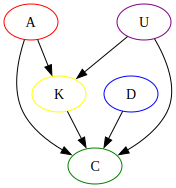

In [4]:
g = gr()
g.attr(rankdir="lr")
g.node(name="A", color="red")
g.node(name="C", color="green")
g.node(name="D", color="blue")
g.node(name="K", color="yellow")
g.node(name="U", color="purple")
g.edge(tail_name="A", head_name="C")
g.edge(tail_name="A", head_name="K")
g.edge(tail_name="K", head_name="C")
g.edge(tail_name="U", head_name="C")
g.edge(tail_name="U", head_name="K")
g.edge(tail_name="D", head_name="C")
g

The adjustment set for this DAG is as follows <br>
We want the causal path $K \rightarrow C$ <br>
There is a fork $K \leftarrow A \rightarrow C$ condition on $A$ to close <br>
Similarly, there is a fork $K \leftarrow U \rightarrow C$ condition on $U$ to close <br>
Total adjustment set becomes $K, A, C$ and $U$ and $C$ will vary by $D$

Plot District Size in Data

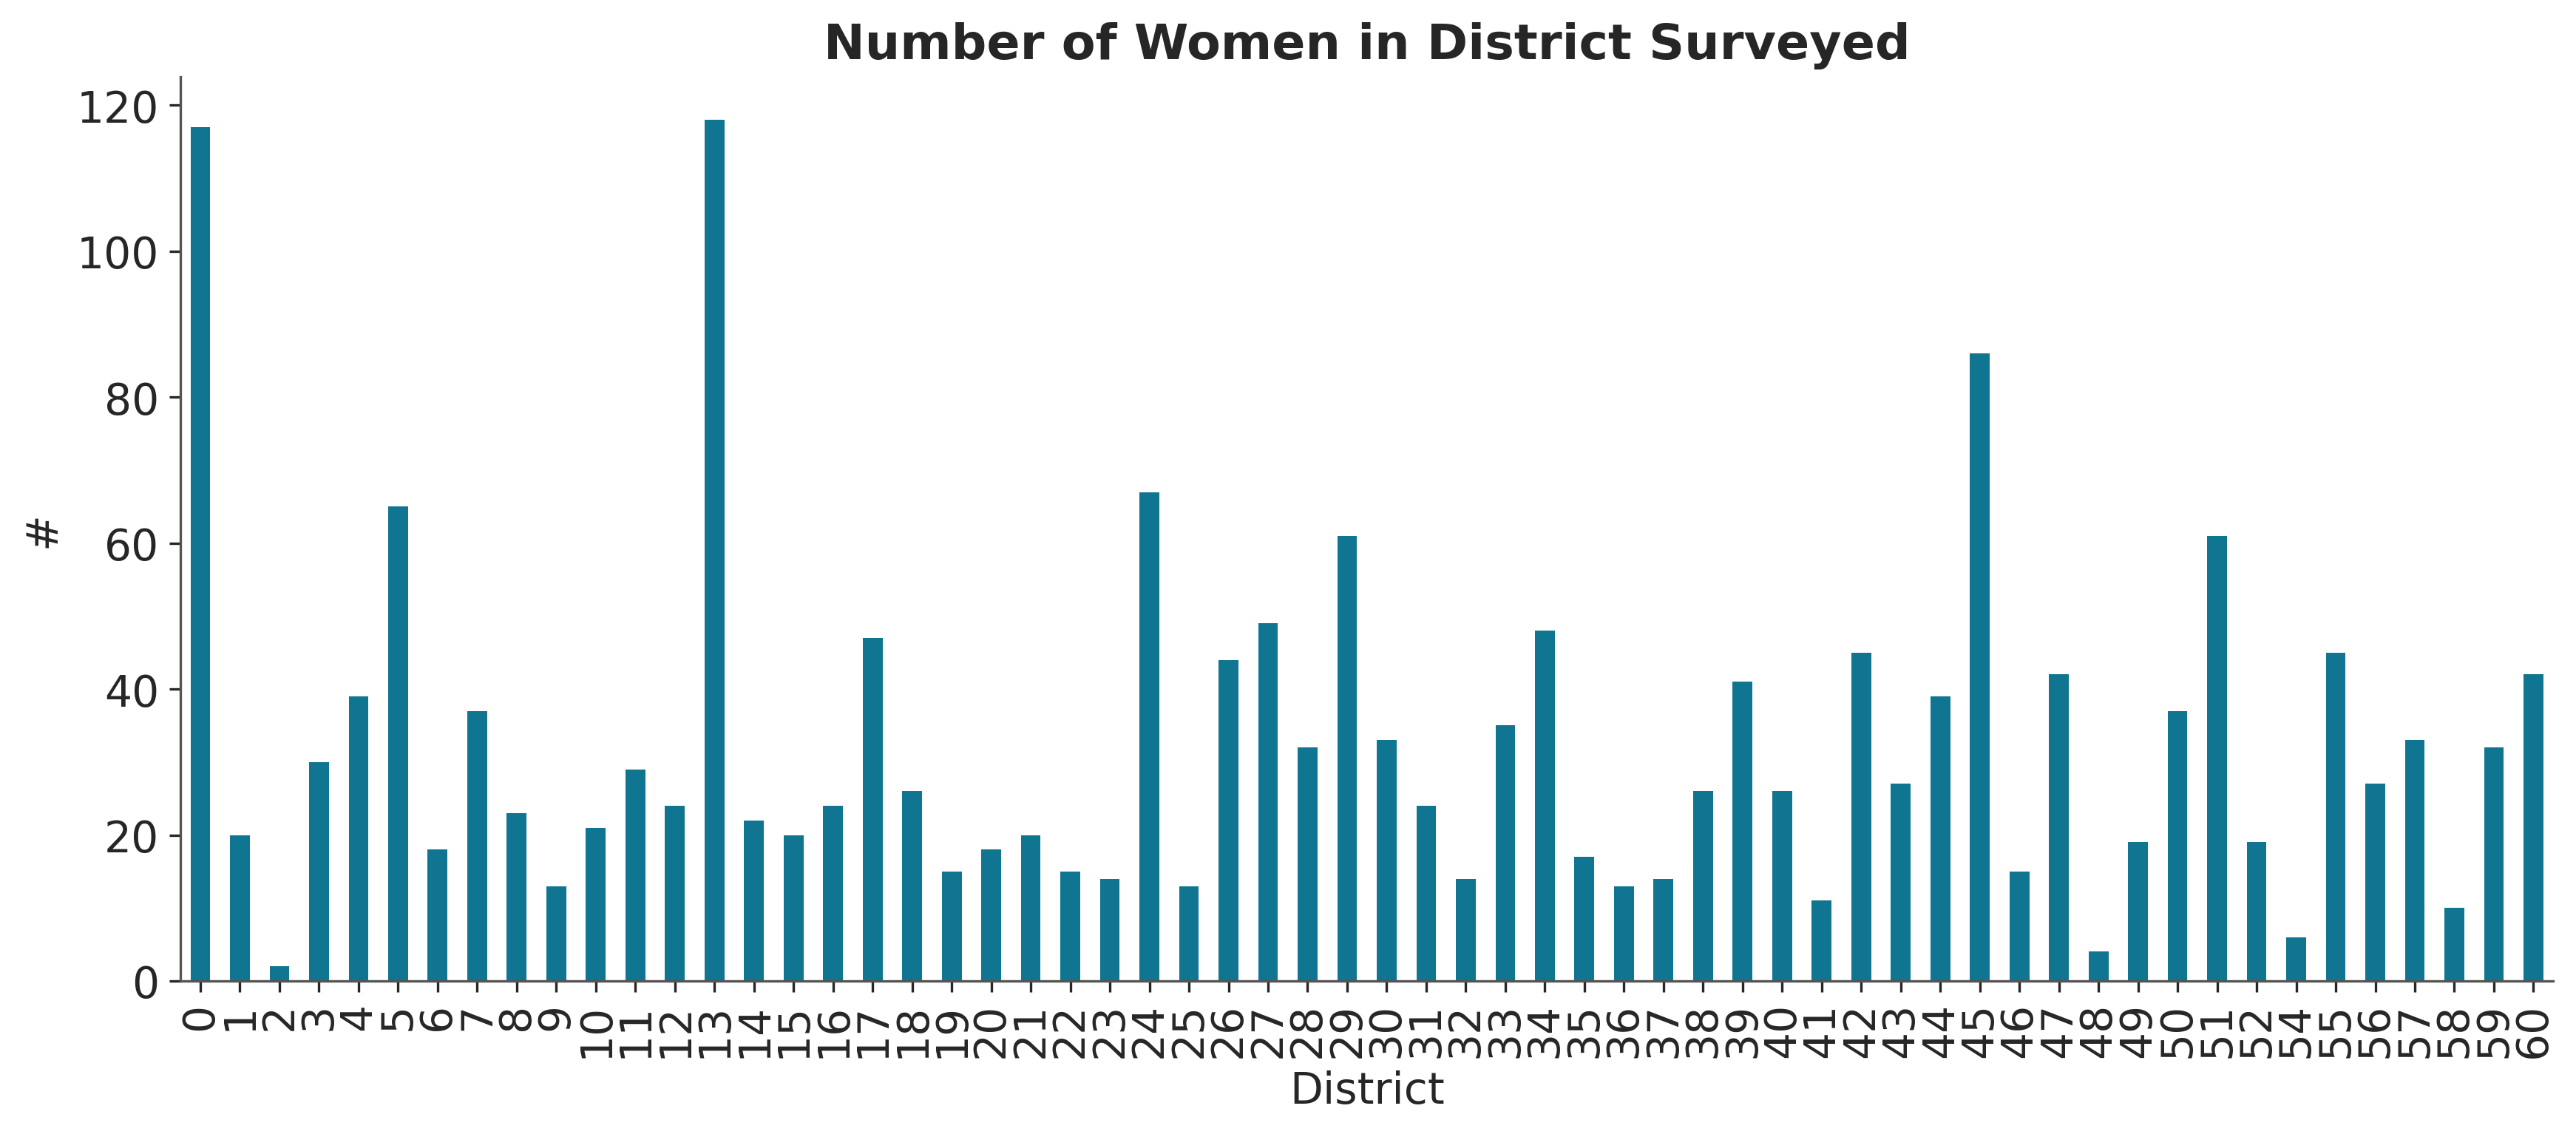

In [5]:
fig, ax = plt.subplots()

summary_df = (
    df
    .groupby("district")
    ["woman"]
    .count()
    .reset_index()
    .sort_values(by="district", ascending=True)
)

summary_df.plot(x="district", y="woman", ax=ax, kind="bar")
ax.set_xlabel("District")
ax.set_ylabel("#")
ax.set_title("Number of Women in District Surveyed")
ax.get_legend().remove()
plt.show()

Plot the contraception use rate

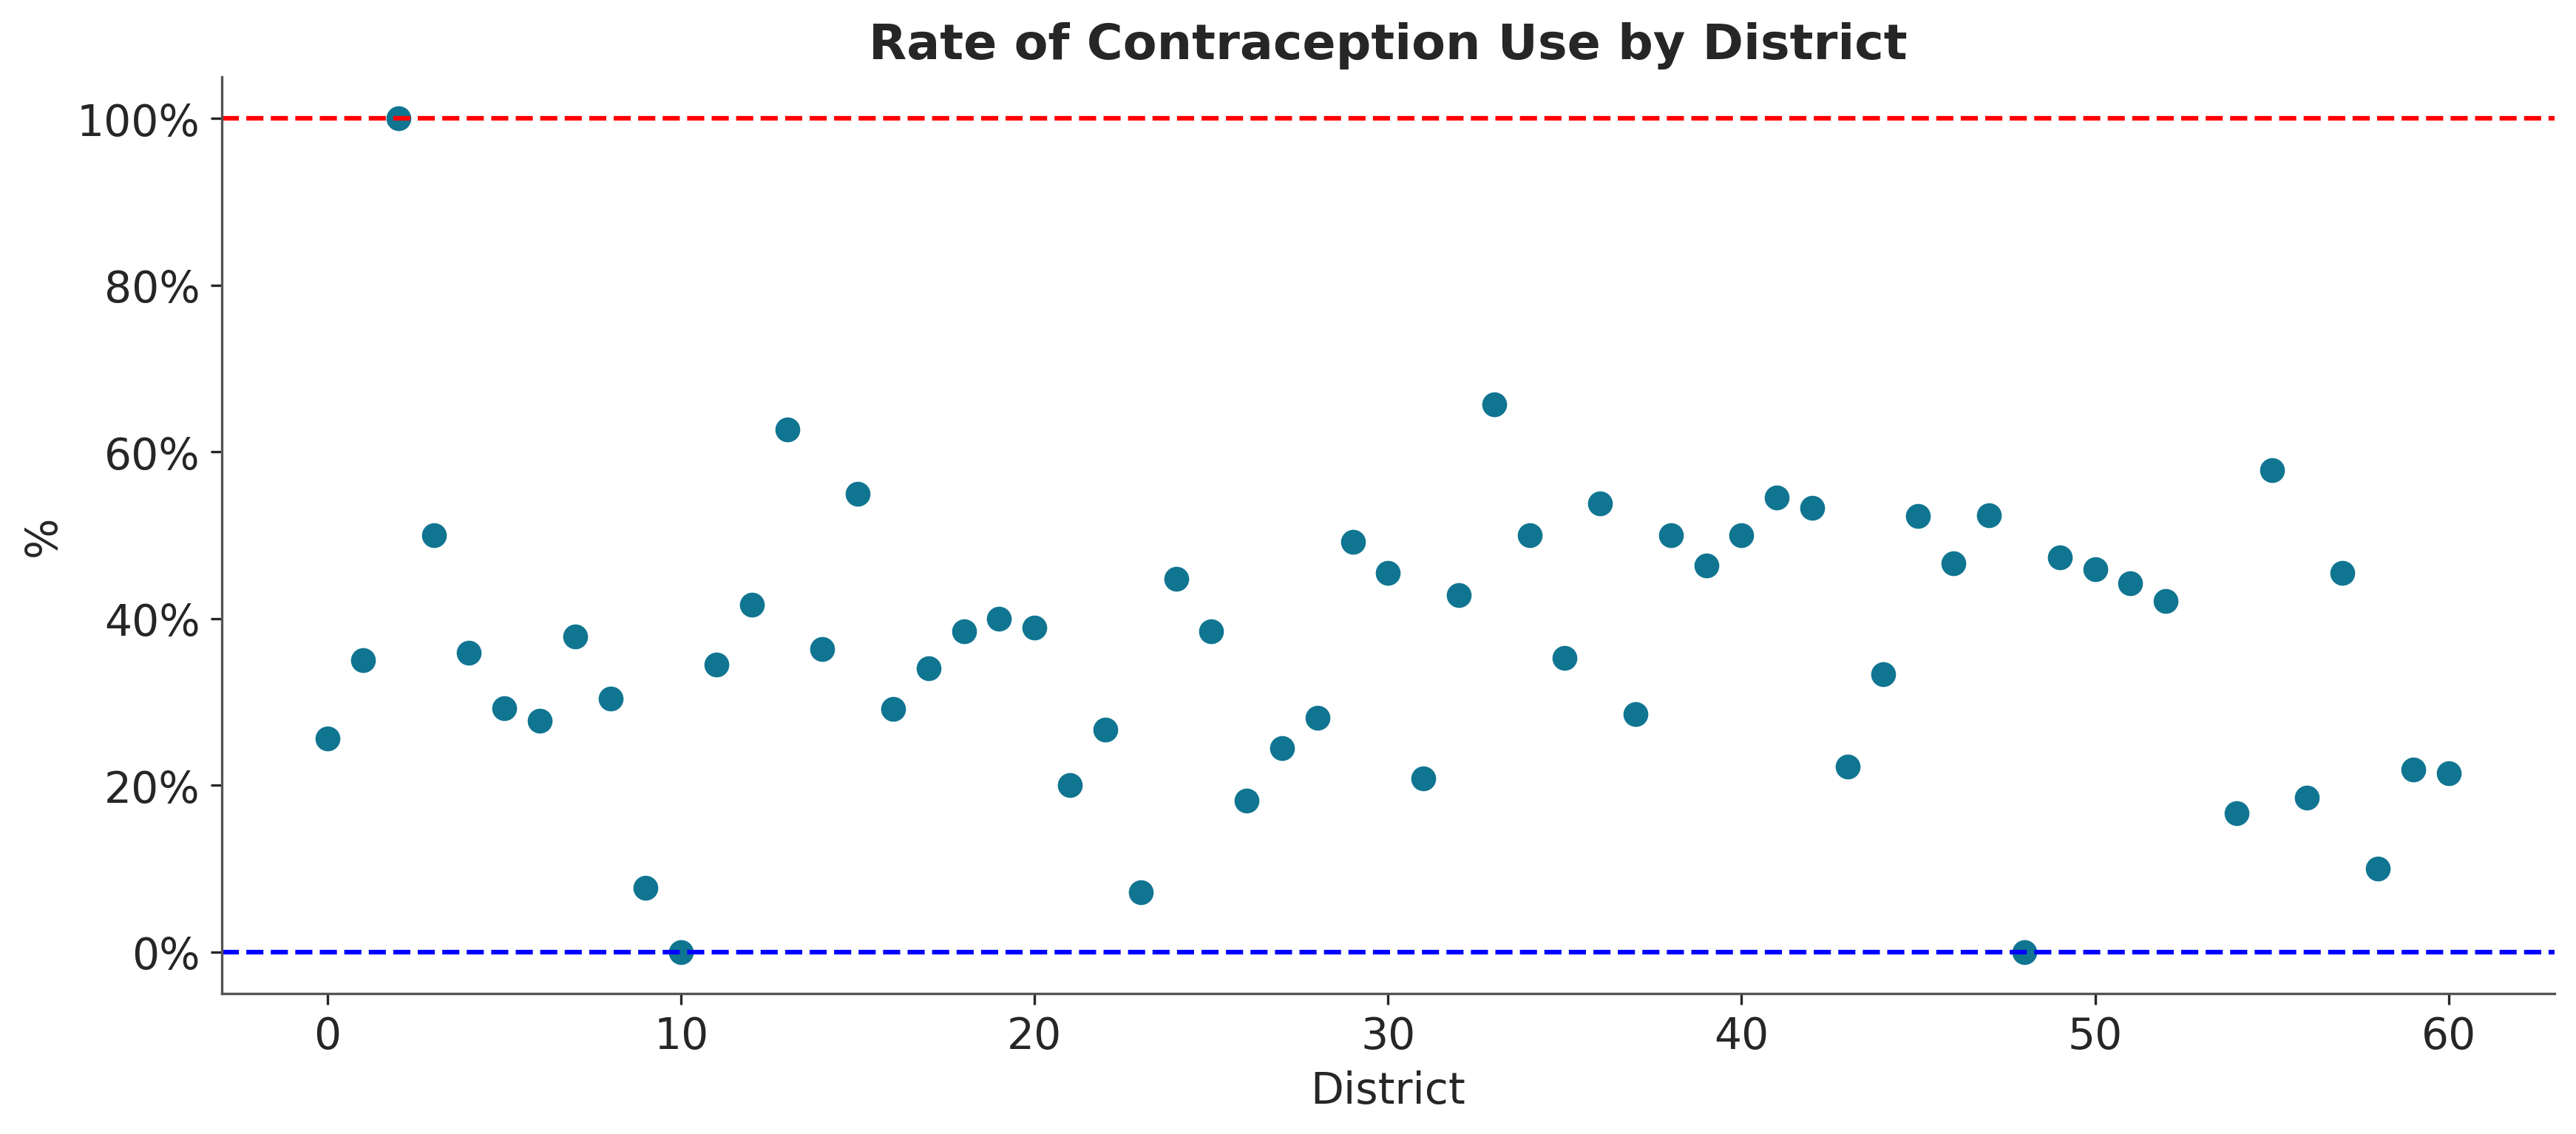

In [6]:
fig, ax = plt.subplots()
summary_df = (
    df
    .groupby("district")
    .agg(
        {"woman": "count",
         "use.contraception": "mean" 
        }
    )
    .reset_index()
    .rename(columns={"woman": "#",
                    "use.contraception": "contraception rate"
                    })
    .sort_values(by="district")
)
summary_df.plot(x="district", y="contraception rate", ax=ax, kind="scatter", s=50)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set(xlabel="District", ylabel="%", title="Rate of Contraception Use by District")
ax.axhline(1.0, ls="--", color="red")
ax.axhline(0.0, ls="--", color="blue")
plt.show()

### Begin Modeling <br>
The model will be partial pooling (hierarchical modeling) using a non-centered effects by district:
<center> $C \sim bernoulli(p)$ </center>
<center> $p = invlogit(a_{D[i]} + b_A \cdot A + b_{UD[i]} \cdot U + b_{KD[i]} \cdot K)$ </center>
<center> $a_{D[i]} \sim \bar{a} + \sigma_a \cdot N(0,1)$</center>
<center> $b_{UD[i]} \sim \bar{b_U} + \sigma_{bU} \cdot N(0,1)$</center>
<center> $b_{KD[i]} \sim \bar{b_K} + \sigma_{bK} \cdot N(0,1)$</center>
Kids, $K$, will be modeled as an ordered monotonic effect

In [7]:
NDistricts = df["district"].max()
KMax = df["living.children"].max()
COORDS = {"district": np.arange(0, NDistricts + 1),
          "obs": np.arange(0, len(df))
         }

In [8]:
with pm.Model(coords=COORDS) as b2_hw:

    # Define Data
    district_id = pm.Data("district_id", df["district"].values, dims="obs") # Subtract 1 so district starts at 0
    A = pm.Data("A", df["age.centered"].values, dims="obs") # Age
    K = pm.Data("K", df["living.children"].values.astype("int"), dims="obs") # Kids will be a monotonic effect
    U = pm.Data("U", df["urban"].values, dims="obs") # Urban
    C = pm.Data("C", df["use.contraception"].values, dims="obs") # Contraception Use (observed)

    # Priors
    # The non-centered Normals that vary by district
    Z_intercept = pm.Normal("Z_intercept", 0, 1, dims="district") # Intercept
    Z_U = pm.Normal("Z_U", 0, 1, dims="district") # Urban
    Z_K = pm.Normal("Z_K", 0, 1, dims="district") # Children

    # Offsets
    a_bar = pm.Normal("a_bar", 0, 1)
    u_bar = pm.Normal("u_bar", 0, 1)
    k_bar = pm.Normal("k_bar", 0, 1)

    # Standard Deviations
    σ_a = pm.Exponential("σ_a", 1)
    σ_u = pm.Exponential("σ_u", 1)
    σ_k = pm.Exponential("σ_k", 1)

    # Prior for age (it won't vary by district)
    bA = pm.Normal("bA", 0, 0.5)

    # Non-centered priors here:
    a = pm.Deterministic("a", a_bar + σ_a * Z_intercept, dims="district")
    b_U = u_bar + σ_u * Z_U
    b_K = k_bar + σ_k * Z_K

    # Monotonic Effect of # of children
    zeta = pm.Dirichlet("zeta", a=pt.ones(KMax))
    ordered_steps = pt.concatenate([pt.zeros(1), pm.math.cumsum(zeta)])
    ordered_K = b_K[district_id] * ordered_steps[K]

    # Total μ
    μ = a[district_id] + b_U[district_id]*U + bA*A + ordered_K

    # Likelihood
    likelihood = pm.Bernoulli("likelihood", p = pm.math.invlogit(μ), observed=C, dims="obs")

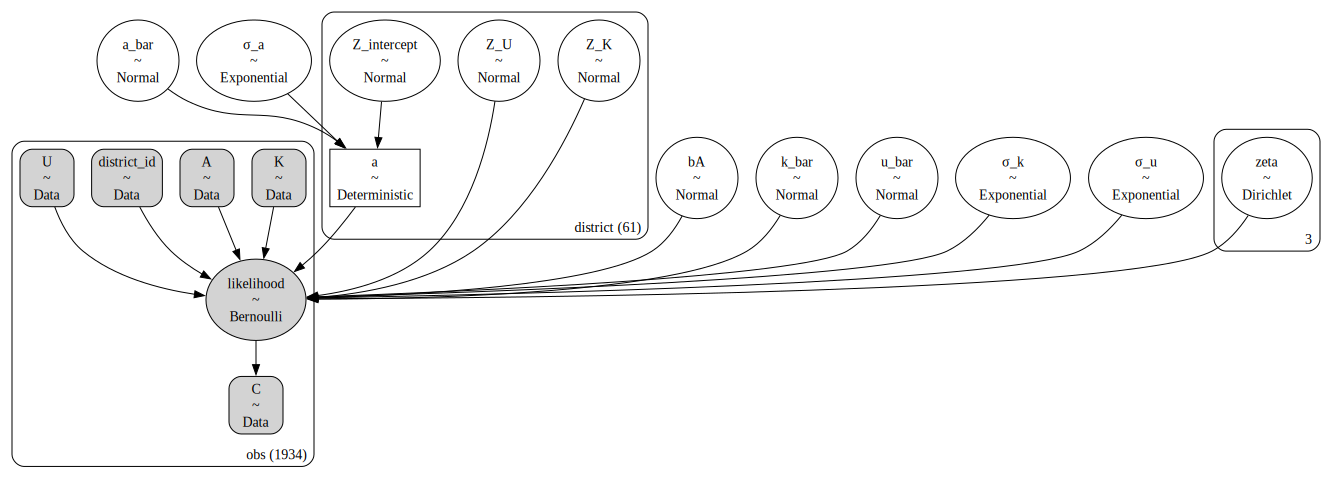

In [9]:
pm.model_to_graphviz(b2_hw)

In [10]:
with b2_hw:
    idata = pm.sample(random_seed=random_seed, target_accept=0.90)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Z_intercept, Z_U, Z_K, a_bar, u_bar, k_bar, σ_a, σ_u, σ_k, bA, zeta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


In [11]:
az.summary(idata, round_to=3, var_names=["zeta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
zeta[0],0.781,0.087,0.622,0.938,0.001,0.001,4582.957,2534.918,1.000
zeta[1],0.144,0.084,0.002,0.288,0.001,0.001,3163.803,1863.683,1.001
zeta[2],0.075,0.056,0.000,0.176,0.001,0.001,4419.462,2727.511,1.001


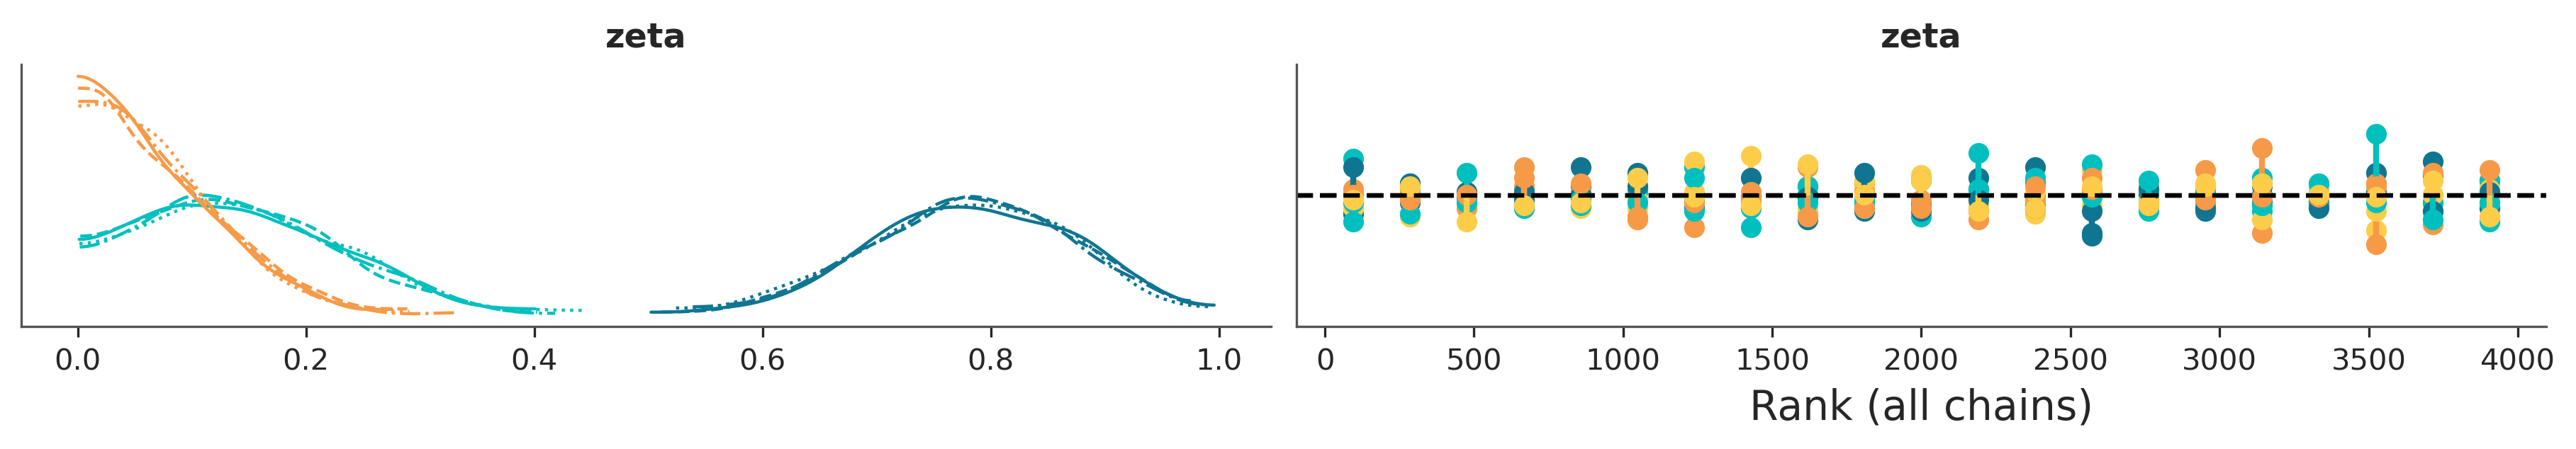

In [12]:
az.plot_trace(idata, var_names="zeta", kind="rank_vlines")
plt.show()

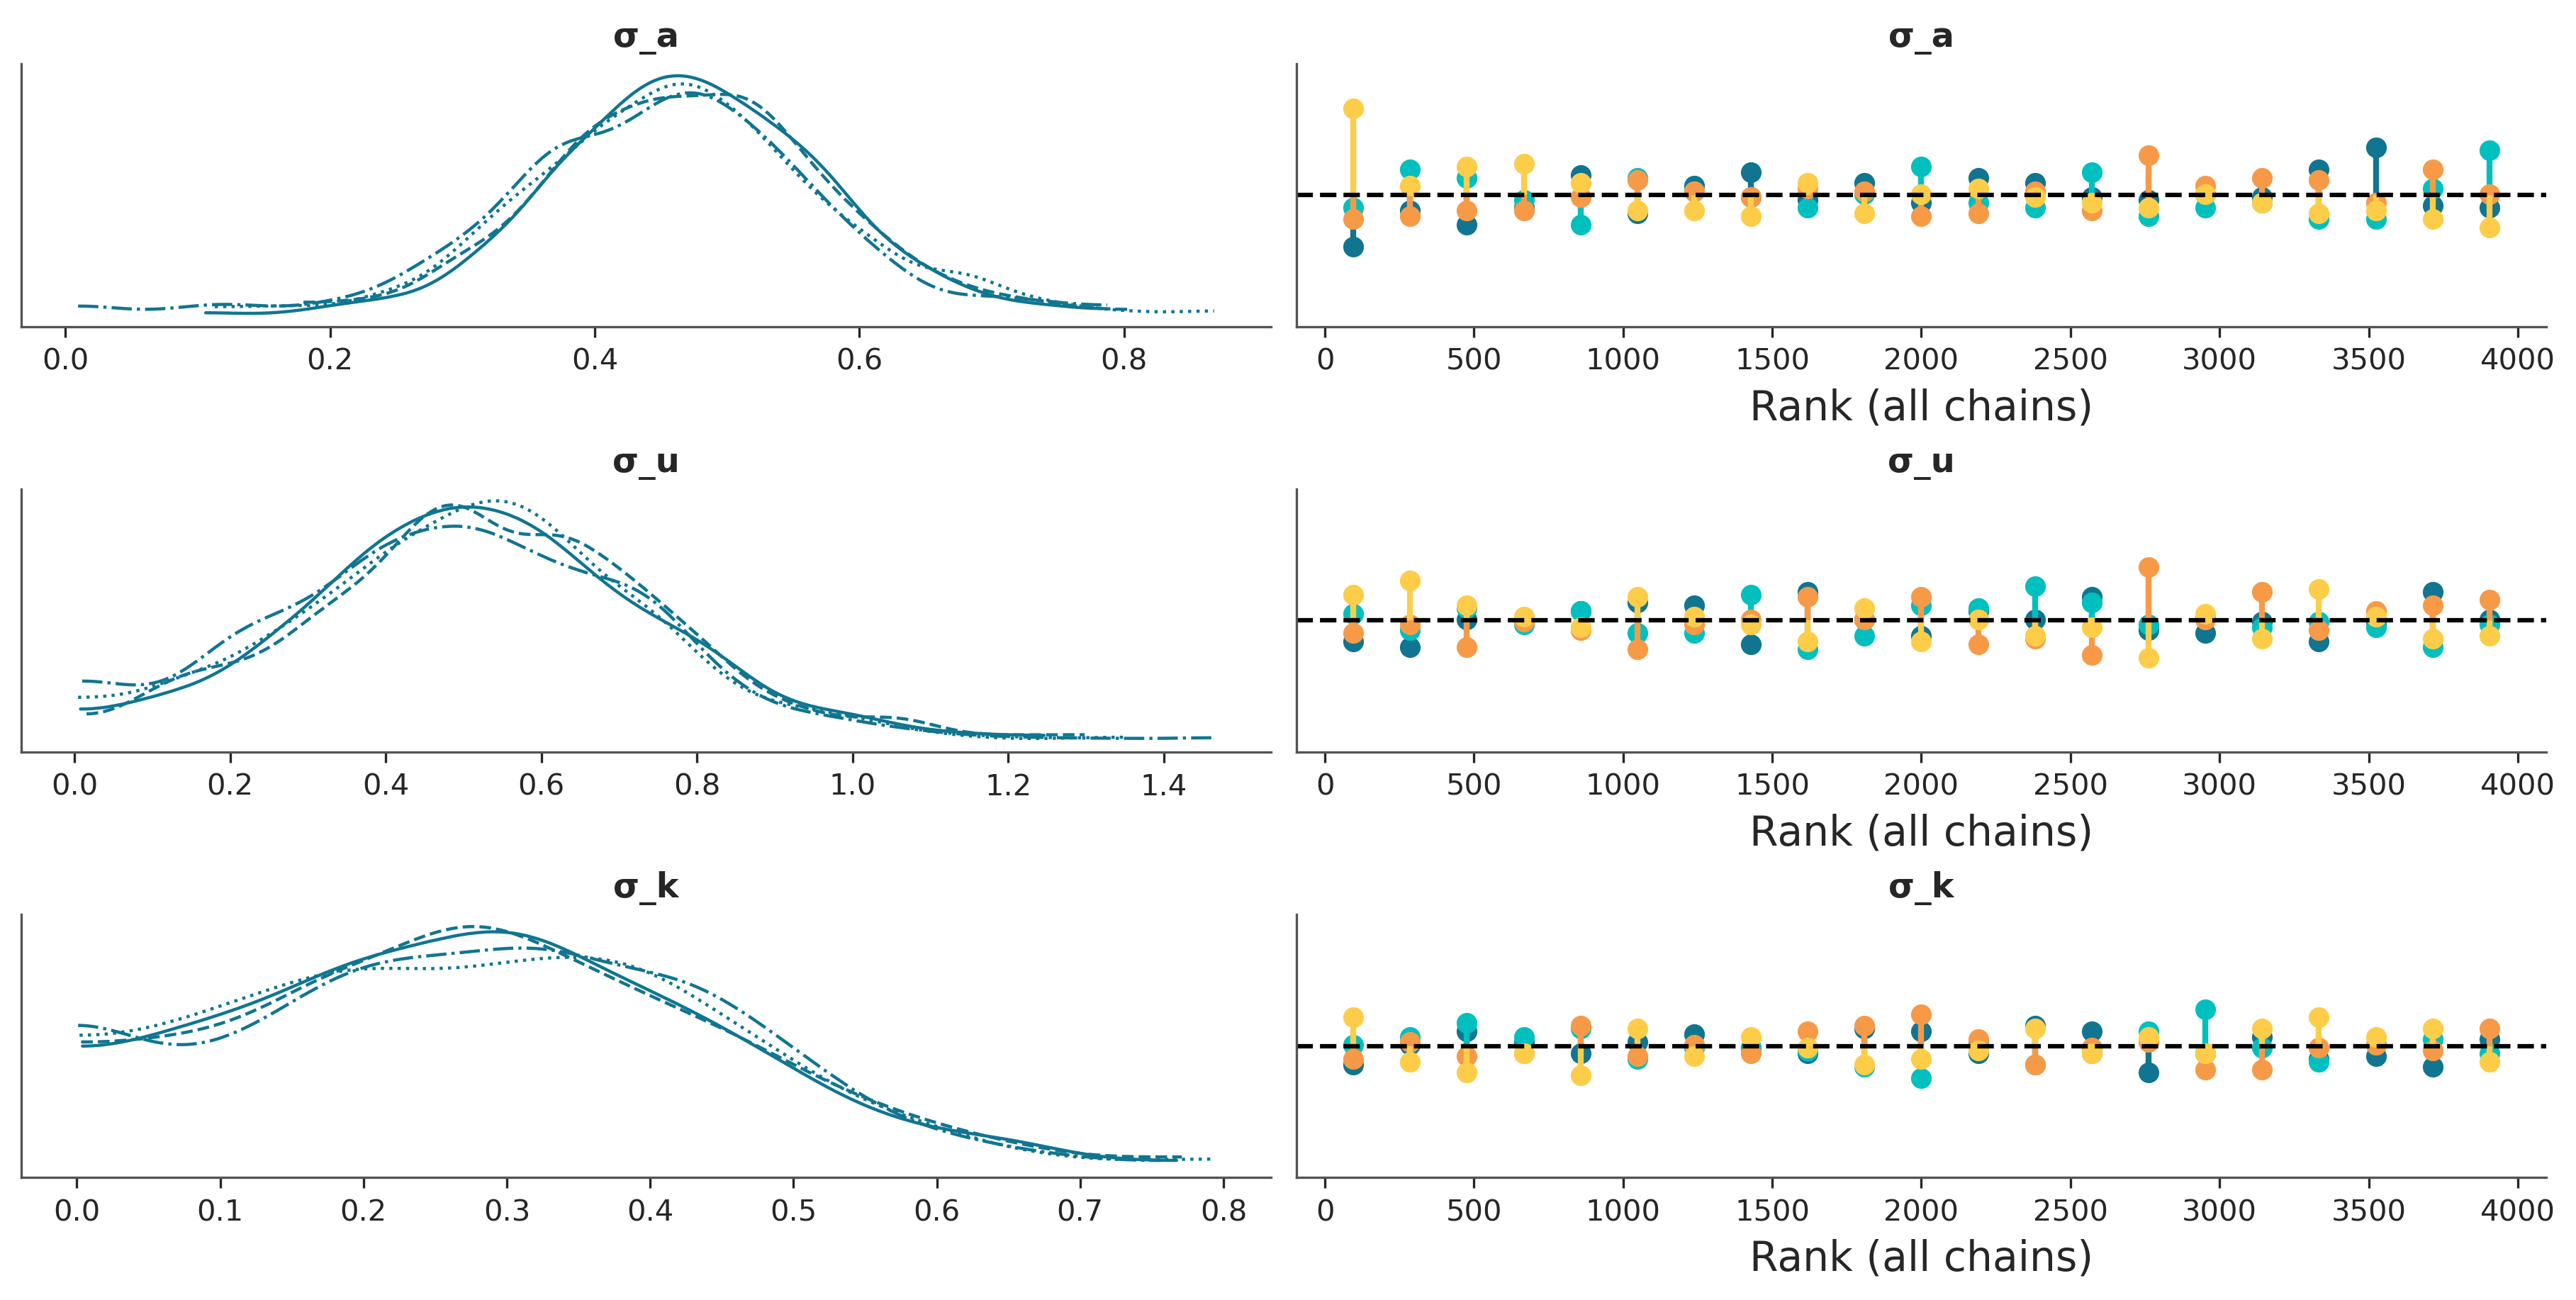

In [13]:
az.plot_trace(idata, var_names=["σ_a", "σ_u", "σ_k"], kind="rank_vlines")
plt.show()

In [14]:
az.summary(idata, var_names=["a"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],-2.29,0.35,-2.96,-1.64,0.01,0.01,1998.41,1761.32,1.0
a[1],-1.68,0.38,-2.38,-0.97,0.00,0.01,6817.97,2794.39,1.0
a[2],-1.44,0.47,-2.31,-0.57,0.01,0.01,7719.78,2801.89,1.0
a[3],-1.61,0.36,-2.29,-0.96,0.00,0.01,5805.23,3245.70,1.0
a[4],-1.59,0.32,-2.19,-0.98,0.00,0.01,5775.97,2922.48,1.0
...,...,...,...,...,...,...,...,...,...
a[56],-2.03,0.38,-2.70,-1.29,0.01,0.01,3726.79,2859.50,1.0
a[57],-1.31,0.35,-1.98,-0.67,0.00,0.01,4995.82,3312.89,1.0
a[58],-2.01,0.45,-2.87,-1.20,0.01,0.01,3848.51,3165.15,1.0
a[59],-2.01,0.38,-2.74,-1.31,0.01,0.01,4438.88,3041.71,1.0
